In [1]:
# ==========================================================
# CREATE BALANCED DATASET DIRECTORY
# ==========================================================
print("start")

import os


balanced_dataset = r"D:/Thesis_folder/Preprocessed_Pipeline/Supervised_Balanced"



print("Balanced dataset ready")


start
Balanced dataset ready


In [2]:
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
print("TensorFlow Version: ", tf.__version__)


Num GPUs Available:  1
TensorFlow Version:  2.10.0


In [3]:
# ==========================================================
# IMPORTS
# ==========================================================
print("start")

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetV2S
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint,
    Callback
)

print("done1")


start
done1


In [4]:
# ==========================================================
# CONFIGURATION & GENERATORS
# ==========================================================
print("start")

# Pointing to the Balanced Dataset
DATASET_PATH = r"D:/Thesis_folder/Preprocessed_Pipeline/Supervised_Balanced"

IMAGE_SIZE = (288, 288)
MODEL_INPUT_SIZE = (288, 288, 3)
NUM_CLASSES = 3
BATCH_SIZE = 32
EPOCHS = 150

print("done1")


start
done1


In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input

# 1. Define the base generator
datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

# 2. Define the paths to your new split folders
train_dir = r"D:/Thesis_folder/Preprocessed_Pipeline/Supervised_Balanced/train"
val_dir = r"D:/Thesis_folder/Preprocessed_Pipeline/Supervised_Balanced/val"
test_dir = r"D:/Thesis_folder/Preprocessed_Pipeline/Supervised_Balanced/test"

# 3. Create the Train Generator
train_generator = datagen.flow_from_directory(
    train_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True # Shuffle training data
)

# 4. Create the Validation Generator
val_generator = datagen.flow_from_directory(
    val_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# 5. Create the Test Generator (CRITICAL: shuffle=False for evaluation)
test_generator = datagen.flow_from_directory(
    test_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)


Found 18000 images belonging to 3 classes.
Found 2965 images belonging to 3 classes.
Found 2943 images belonging to 3 classes.


In [6]:
import tensorflow as tf
import tensorflow_addons as tfa
print("start")

# Initializing the metrics, now including Recall
f1_metric = tfa.metrics.F1Score(num_classes=3, average='macro', name='f1_score')
precision_metric = tf.keras.metrics.Precision(name='precision')
recall_metric = tf.keras.metrics.Recall(name='recall') # <-- Added Recall metric

def get_EfficientNetV2S():

    base_model = EfficientNetV2S(
        input_shape=MODEL_INPUT_SIZE,
        weights='imagenet',
        include_top=False
    )

    base_model.trainable = False

    model = Sequential([
        base_model,
        GlobalAveragePooling2D(),                
        tf.keras.layers.Dropout(0.3),            
        Dense(NUM_CLASSES, activation='softmax') 
    ])

    # Keep your original optimizer configuration
    optimizer = Adam(learning_rate=0.0001)

    # Compiling with your requested metrics (now including recall)
    model.compile(
        loss="categorical_crossentropy",
        metrics=["accuracy", f1_metric, precision_metric, recall_metric], # <-- Added to compile
        optimizer=optimizer
    )

    return model

model = get_EfficientNetV2S()
model.summary()

print("done1")


start
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 efficientnetv2-s (Functiona  (None, 9, 9, 1280)       20331360  
 l)                                                              
                                                                 
 global_average_pooling2d (G  (None, 1280)             0         
 lobalAveragePooling2D)                                          
                                                                 
 dropout (Dropout)           (None, 1280)              0         
                                                                 
 dense (Dense)               (None, 3)                 3843      
                                                                 
Total params: 20,335,203
Trainable params: 3,843
Non-trainable params: 20,331,360
_________________________________________________________________
done1


In [7]:
# ==========================================================
# CALLBACKS (Monitor set to 'val_f1_score')
# ==========================================================
print("start")

early_stop = EarlyStopping(
    monitor='val_f1_score',
    mode='max',
    patience=11,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_f1_score',
    mode='max',
    factor=0.3,
    patience=5,
    min_lr=5e-8,
    verbose=1
)

checkpoint = ModelCheckpoint(
"EfficientNetV2S_balanced_model_V1.h5",
    monitor='val_f1_score',
    save_best_only=True,
    save_weights_only=True,
    mode='max',
    verbose=1
)

print("done")


start
done


In [8]:
# ==========================================================
# SHOW LEARNING RATE
# ==========================================================
print("start")

class PrintLearningRate(Callback):
    def on_epoch_end(self, epoch, logs=None):
        lr = self.model.optimizer.learning_rate.numpy()
        print(f"\nEpoch {epoch+1} Learning Rate : {lr}")

lr_callback = PrintLearningRate()

print("done1")


start
done1


In [9]:
# ==========================================================
# TRAINING
# ==========================================================
print("start")

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint,
        lr_callback
    ]
)
print("done")


start
Epoch 1/150
563/563 [==============================] - ETA: 0s - loss: 1.0303 - accuracy: 0.4709 - f1_score: 0.4703 - precision: 0.5669 - recall: 0.2219
Epoch 1: val_f1_score improved from -inf to 0.58994, saving model to EfficientNetV2S_balanced_model_V1.h5

Epoch 1 Learning Rate : 9.999999747378752e-05
563/563 [==============================] - 457s 799ms/step - loss: 1.0303 - accuracy: 0.4709 - f1_score: 0.4703 - precision: 0.5669 - recall: 0.2219 - val_loss: 0.8989 - val_accuracy: 0.5936 - val_f1_score: 0.5899 - val_precision: 0.7184 - val_recall: 0.3777 - lr: 1.0000e-04
Epoch 2/150
563/563 [==============================] - ETA: 0s - loss: 0.9111 - accuracy: 0.5687 - f1_score: 0.5646 - precision: 0.6537 - recall: 0.3882
Epoch 2: val_f1_score improved from 0.58994 to 0.61499, saving model to EfficientNetV2S_balanced_model_V1.h5

Epoch 2 Learning Rate : 9.999999747378752e-05
563/563 [==============================] - 168s 299ms/step - loss: 0.9111 - accuracy: 0.5687 - f1_score

In [10]:
# 1. Rebuild the model architecture blueprint first
model = get_EfficientNetV2S()

# 2. Load the weights directly into the blueprint
# Note: .load_weights() does not require a custom_objects dictionary!
model.load_weights("EfficientNetV2S_balanced_model_V1.h5")

print("Model weights loaded successfully!")


Model weights loaded successfully!


start


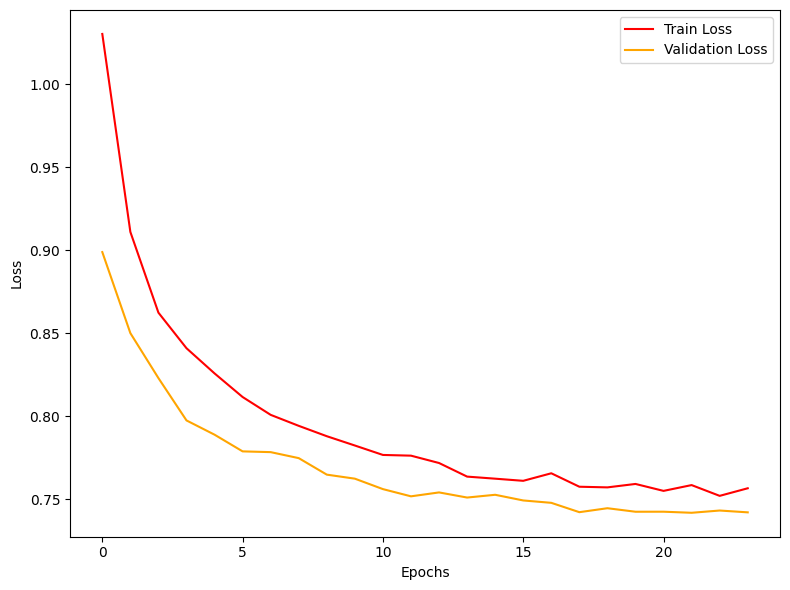

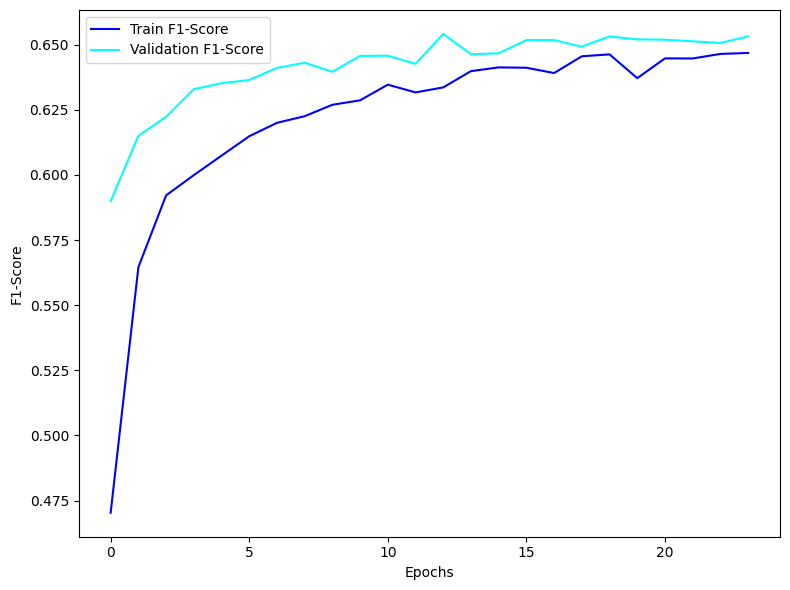

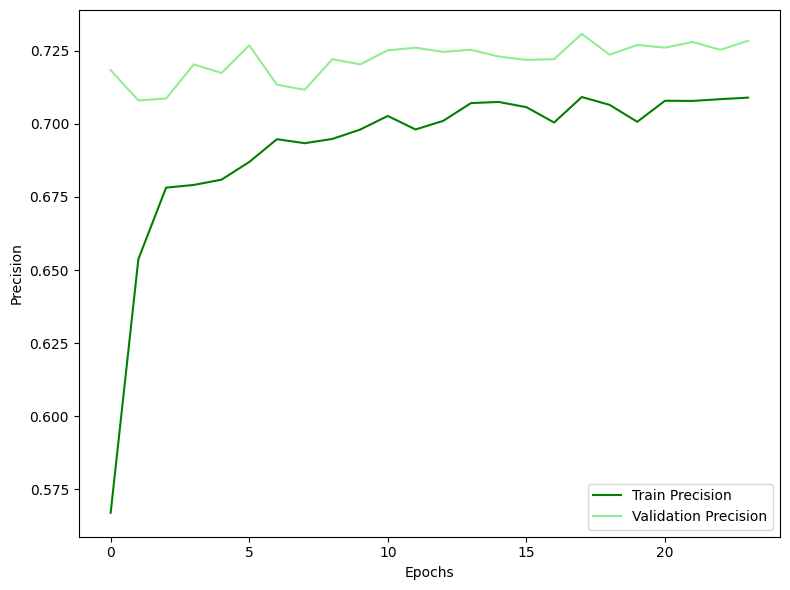

done1


In [11]:
# ==========================================================
# PLOT LEARNING CURVES (Loss, F1-Score, Precision)
# ==========================================================
print("start")

# 1. Loss Curve
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Train Loss', color='red')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.savefig("EfficientNetV2S_balanced_Loss_Curve.pdf", format='pdf', bbox_inches='tight')
plt.show()

# 2. F1 Score Curve
plt.figure(figsize=(8, 6))
plt.plot(history.history['f1_score'], label='Train F1-Score', color='blue')
plt.plot(history.history['val_f1_score'], label='Validation F1-Score', color='cyan')

plt.xlabel('Epochs')
plt.ylabel('F1-Score')
plt.legend()
plt.tight_layout()
plt.savefig("EfficientNetV2S_balanced_F1_Curve.pdf", format='pdf', bbox_inches='tight')
plt.show()

# 3. Precision Curve
plt.figure(figsize=(8, 6))
plt.plot(history.history['precision'], label='Train Precision', color='green')
plt.plot(history.history['val_precision'], label='Validation Precision', color='lightgreen')
plt.xlabel('Epochs')
plt.ylabel('Precision')
plt.legend()
plt.tight_layout()
plt.savefig("EfficientNetV2S_balanced_Precision_Curve.pdf", format='pdf', bbox_inches='tight')
plt.show()

print("done1")


In [12]:
# ==========================================================
# EVALUATION (Training, Validation & Testing)
# ==========================================================
print("Evaluating on Training Set...")
train_results = model.evaluate(train_generator)

print("\nEvaluating on Validation Set...")
val_results = model.evaluate(val_generator)

print("\nEvaluating on Testing Set (Truly Unseen)...")
test_results = model.evaluate(test_generator)

# Unpacking 5 values based on the compile metrics order
# Order: [loss, accuracy, f1_score, precision, recall]
train_loss = train_results[0]
train_acc = train_results[1]
train_f1 = train_results[2]
train_precision = train_results[3]
train_recall = train_results[4]

val_loss = val_results[0]
val_acc = val_results[1]
val_f1 = val_results[2]
val_precision = val_results[3]
val_recall = val_results[4]

test_loss = test_results[0]
test_acc = test_results[1]
test_f1 = test_results[2]
test_precision = test_results[3]
test_recall = test_results[4]

print("\n" + "="*40)
print("TRAINING METRICS")
print("="*40)
print(f"Training Loss      : {train_loss:.4f}")
print(f"Training Accuracy  : {train_acc*100:.2f}%")
print(f"Training F1-Score  : {train_f1*100:.2f}%")
print(f"Training Precision : {train_precision*100:.2f}%")
print(f"Training Recall    : {train_recall*100:.2f}%")

print("\n" + "="*40)
print("VALIDATION METRICS")
print("="*40)
print(f"Validation Loss      : {val_loss:.4f}")
print(f"Validation Accuracy  : {val_acc*100:.2f}%")
print(f"Validation F1-Score  : {val_f1*100:.2f}%")
print(f"Validation Precision : {val_precision*100:.2f}%")
print(f"Validation Recall    : {val_recall*100:.2f}%")

print("\n" + "="*40)
print("TESTING METRICS (UNSEEN DATA)")
print("="*40)
print(f"Testing Loss      : {test_loss:.4f}")
print(f"Testing Accuracy  : {test_acc*100:.2f}%")
print(f"Testing F1-Score  : {test_f1*100:.2f}%")
print(f"Testing Precision : {test_precision*100:.2f}%")
print(f"Testing Recall    : {test_recall*100:.2f}%")


Evaluating on Training Set...
563/563 [==============================] - 131s 230ms/step - loss: 0.7285 - accuracy: 0.6642 - f1_score: 0.6617 - precision: 0.7355 - recall: 0.5588

Evaluating on Validation Set...
93/93 [==============================] - 22s 233ms/step - loss: 0.7542 - accuracy: 0.6563 - f1_score: 0.6541 - precision: 0.7247 - recall: 0.5450

Evaluating on Testing Set (Truly Unseen)...
92/92 [==============================] - 36s 392ms/step - loss: 0.7761 - accuracy: 0.6256 - f1_score: 0.6210 - precision: 0.7020 - recall: 0.5202

TRAINING METRICS
Training Loss      : 0.7285
Training Accuracy  : 66.42%
Training F1-Score  : 66.17%
Training Precision : 73.55%
Training Recall    : 55.88%

VALIDATION METRICS
Validation Loss      : 0.7542
Validation Accuracy  : 65.63%
Validation F1-Score  : 65.41%
Validation Precision : 72.47%
Validation Recall    : 54.50%

TESTING METRICS (UNSEEN DATA)
Testing Loss      : 0.7761
Testing Accuracy  : 62.56%
Testing F1-Score  : 62.10%
Testing Pre

In [13]:
# ==========================================================
# PRECISION, RECALL, F1-SCORE (Test Set - Unseen Data)
# ==========================================================
print("\nCalculating Precision, Recall, F1-score on Test Set...")

predictions = model.predict(test_generator)
predicted_classes = np.argmax(predictions, axis=1)

true_classes = test_generator.classes
class_names = list(test_generator.class_indices.keys())

print("\nClassification Report (Test Set):\n")
print(
    classification_report(
        true_classes,
        predicted_classes,
        target_names=class_names
    )
)

print("done1")



Calculating Precision, Recall, F1-score on Test Set...
92/92 [==============================] - 22s 229ms/step

Classification Report (Test Set):

              precision    recall  f1-score   support

      Benign       0.50      0.49      0.49       888
   Malignant       0.69      0.65      0.67      1266
      Normal       0.66      0.74      0.70       789

    accuracy                           0.63      2943
   macro avg       0.62      0.63      0.62      2943
weighted avg       0.63      0.63      0.62      2943

done1


Generating Confusion Matrix...


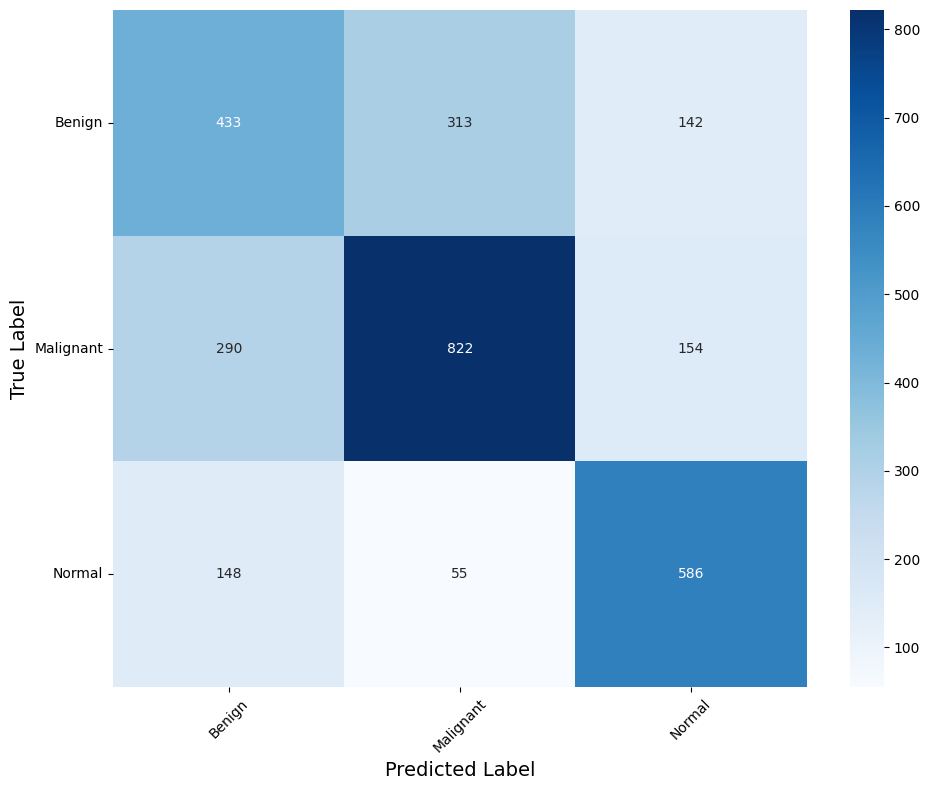

done1


In [14]:
# ==========================================================
# CONFUSION MATRIX (Test Set)
# ==========================================================
print("Generating Confusion Matrix...")

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(true_classes, predicted_classes)

# Plot the confusion matrix using Seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,       # Show the actual numbers inside the squares
    fmt='d',          # Format as whole numbers (integers)
    cmap='Blues',     # Color scheme
    xticklabels=class_names,
    yticklabels=class_names
)


plt.ylabel('True Label', fontsize=14)
plt.xlabel('Predicted Label', fontsize=14)
plt.xticks(rotation=45) # Rotate x-axis labels so they are easier to read
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig("EfficientNetV2S_balanced_confusion_matrix_test.pdf", format='pdf', bbox_inches='tight')
plt.show()

print("done1")
